In [1]:
import pandas as pd
import matplotlib
from matplotlib import pyplot as plt
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (10,6)

We will use the heights dataset from kaggle. Dataset has heights and weights but we will remove weights to make things simpler

https://www.kaggle.com/mustafaali96/weight-height

In [2]:
df = pd.read_csv('heights.csv')
df.sample(5)

,gender,height
4829,Male,70.378608
1615,Male,68.768902
7046,Female,67.511362
3987,Male,71.469185
3328,Male,70.660250


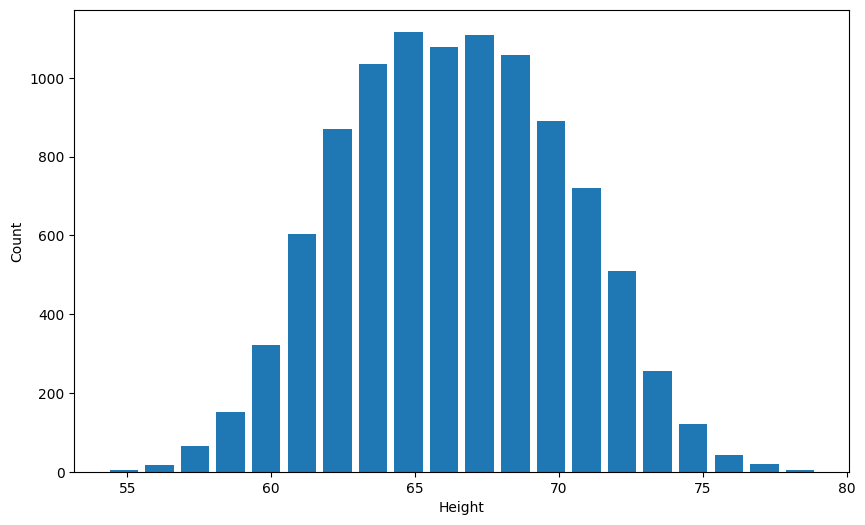

In [3]:
plt.hist(df.height, bins=20, rwidth=0.8)
plt.xlabel('Height')
plt.ylabel('Count')
plt.show()

###Plot bell curve

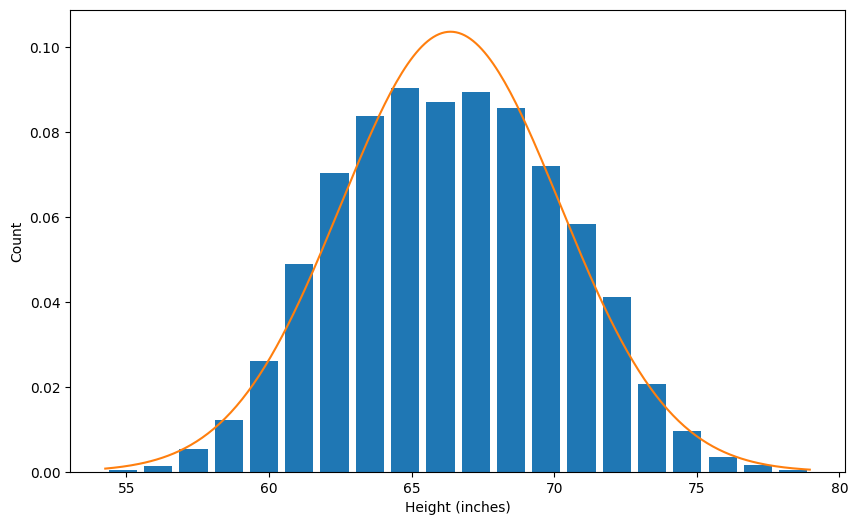

In [4]:
from scipy.stats import norm
import numpy as np

plt.hist(df.height, bins=20, rwidth=0.8, density=True)
plt.xlabel('Height (inches)')
plt.ylabel('Count')

rng = np.arange(df.height.min(), df.height.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df.height.mean(), df.height.std()))

In [5]:
df.height.mean()

np.float64(66.367559754866)

In [6]:
df.height.std()

3.847528120795573

###Outlier detection and removal using 3 std

We can remove data points that are beyond 3 std from the mean

In [7]:
upper_limit = df.height.mean() + 3*df.height.std()
upper_limit

np.float64(77.91014411725271)

In [8]:
lower_limit = df.height.mean() -3*df.height.std()
lower_limit

np.float64(54.824975392479274)

In [10]:
df[(df.height<lower_limit) | (df.height>upper_limit)]

,gender,height
994,Male,78.095867
1317,Male,78.462053
2014,Male,78.998742
3285,Male,78.528210
3757,Male,78.621374
6624,Female,54.616858
9285,Female,54.263133


In [11]:
df_no_outlier_std_dev = df[(df.height<upper_limit) & (df.height>lower_limit)]
df_no_outlier_std_dev.head()

,gender,height
0,Male,73.847017
1,Male,68.781904
2,Male,74.110105
3,Male,71.730978
4,Male,69.881796


In [12]:
df_no_outlier_std_dev.shape

(9993, 2)

In [13]:
df.shape

(10000, 2)

###Outlier detection and removal using Z score

Z score indicates how many std away a data point is

Here mean is 66.37 and standard deviation is 3.85

If the value of a data point is 77.91, then its Z score is 3 because it is 3 std away (77.91 ≈ 66.37 + 3 * 3.85)

In [14]:
df['zscore'] = (df.height - df.height.mean())/df.height.std()
df.head(5)

,gender,height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


Get data points that has z score > 3 or < -3. They are more than 3 std away from the mean.

In [15]:
df[df.zscore>3]

,gender,height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854


In [16]:
df[df.zscore<-3]

,gender,height,zscore
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [17]:
df[(df.zscore<-3) | (df.zscore>3)]

,gender,height,zscore
994,Male,78.095867,3.048271
1317,Male,78.462053,3.143445
2014,Male,78.998742,3.282934
3285,Male,78.528210,3.160640
3757,Male,78.621374,3.184854
6624,Female,54.616858,-3.054091
9285,Female,54.263133,-3.146027


In [18]:
df_no_outliers = df[(df.zscore>-3) & (df.zscore<3)]
df_no_outliers.head()

,gender,height,zscore
0,Male,73.847017,1.943964
1,Male,68.781904,0.627505
2,Male,74.110105,2.012343
3,Male,71.730978,1.393991
4,Male,69.881796,0.913375


In [19]:
df_no_outliers.shape

(9993, 3)

In [20]:
df.shape

(10000, 3)

###Another dataset: Property prices in Bangalore, India

Let's remove outliers using standard deviation and z score

(1) Remove outliers using percentile. Use [0.001, 0.999] for lower and upper bound percentiles

(2) After removing outliers in step 1, get a new dataframe.

(3) On step(2)'s dataframe, remove outliers 4 std away from mean

(4) Plot a histogram for the new dataframe generated after step (3). Also plot a bell curve

(5) On step(2)'s dataframe, use zscore to remove outliers. This is similar to step (3) and we will get the exact same result

In [21]:
df = pd.read_csv('bhp.csv')
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [22]:
df.price_per_sqft.describe()

,price_per_sqft
count,1.320000e+04
mean,7.920337e+03
std,1.067272e+05
min,2.670000e+02
25%,4.267000e+03
50%,5.438000e+03
75%,7.317000e+03
max,1.200000e+07


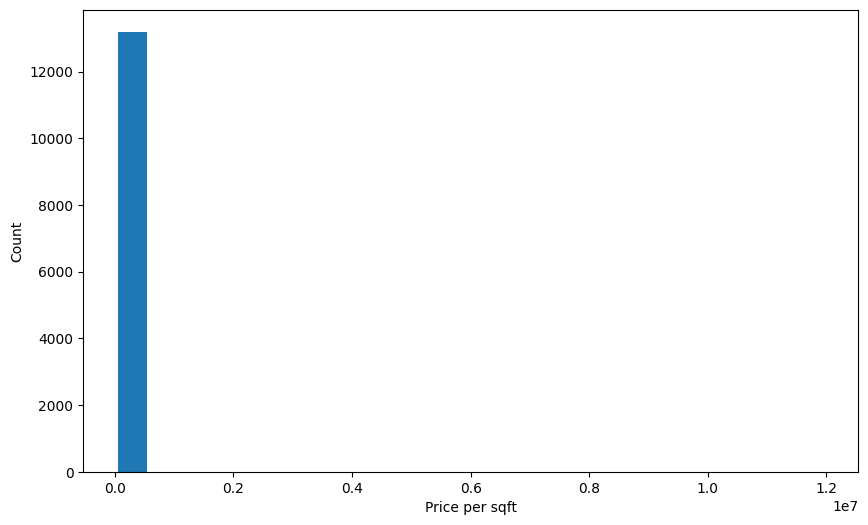

In [23]:
plt.hist(df.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel('Price per sqft')
plt.ylabel('Count')
plt.show()

This confirms that the dataset has bad outliers. We see only one bar with more than 12000 data points, but on the right, there are data points that have higher values of price per sqft. These data points are tiny.

Let's use log scale to make visualization better

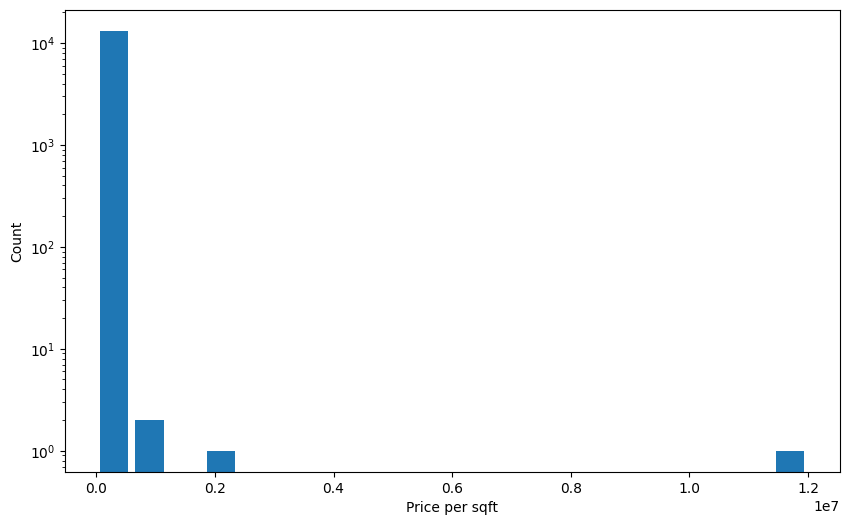

In [24]:
plt.hist(df.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel('Price per sqft')
plt.ylabel('Count')
plt.yscale('log')
plt.show()

###Treat outliers using percentile

In [25]:
lower_limit, upper_limit = df.price_per_sqft.quantile([0.001, 0.999])
lower_limit, upper_limit

(1366.184, 50959.36200000098)

In [26]:
outliers = df[(df.price_per_sqft>upper_limit) | (df.price_per_sqft<lower_limit)]
outliers.sample(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
5417,Ulsoor,4 BHK,36000.0,4.0,450.0,4,1250
8300,Kengeri,1 BHK,1200.0,1.0,14.0,1,1166
11635,Begur,3 BHK,2400.0,3.0,12.0,3,500
665,Yelahanka,3 BHK,35000.0,3.0,130.0,3,371
7012,other,1 BHK,650.0,1.0,500.0,1,76923
9436,Indira Nagar,4 Bedroom,2400.0,5.0,1250.0,4,52083
798,other,4 Bedroom,10961.0,4.0,80.0,4,729
12355,other,4 BHK,16335.0,4.0,149.0,4,912
7575,other,1 BHK,425.0,1.0,750.0,1,176470
5911,Mysore Road,1 Bedroom,45.0,1.0,23.0,1,51111


In [27]:
df2 = df[(df.price_per_sqft<upper_limit) & (df.price_per_sqft>lower_limit)]
df2.shape

(13172, 7)

In [28]:
df.shape

(13200, 7)

In [29]:
df.shape[0] - df2.shape[0]

28

We've removed 28 outliers

###Remove outliers using 4 std

In [30]:
max_limit = df2.price_per_sqft.mean() + 4*df2.price_per_sqft.std()
min_limit = df2.price_per_sqft.mean() - 4*df2.price_per_sqft.std()
max_limit, min_limit

(np.float64(23227.73653589429), np.float64(-9900.429065502549))

In [31]:
df2[(df2.price_per_sqft>max_limit) | (df2.price_per_sqft<min_limit)].sample(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
2371,other,5 Bedroom,3000.0,6.0,1000.0,5,33333
6134,Basavangudi,6 Bedroom,1754.0,6.0,650.0,6,37058
5144,Rajaji Nagar,3 Bedroom,2790.0,3.0,950.0,3,34050
12678,Chikkalasandra,5 Bedroom,1000.0,4.0,300.0,5,30000
6709,Malleshwaram,4 Bedroom,4000.0,4.0,1100.0,4,27500
2410,other,6 Bedroom,2400.0,8.0,650.0,6,27083
12636,OMBR Layout,5 Bedroom,600.0,3.0,140.0,5,23333
8157,other,4 BHK,2230.0,4.0,792.0,4,35515
9229,1st Phase JP Nagar,4 Bedroom,1200.0,4.0,300.0,4,25000
13081,other,6 Bedroom,8000.0,6.0,2800.0,6,35000


In [32]:
df3 = df2[(df2.price_per_sqft>min_limit) & (df2.price_per_sqft<max_limit)]
df3.shape

(13047, 7)

In [33]:
df2.shape[0]-df3.shape[0]

125

This step we removed 125 outliers

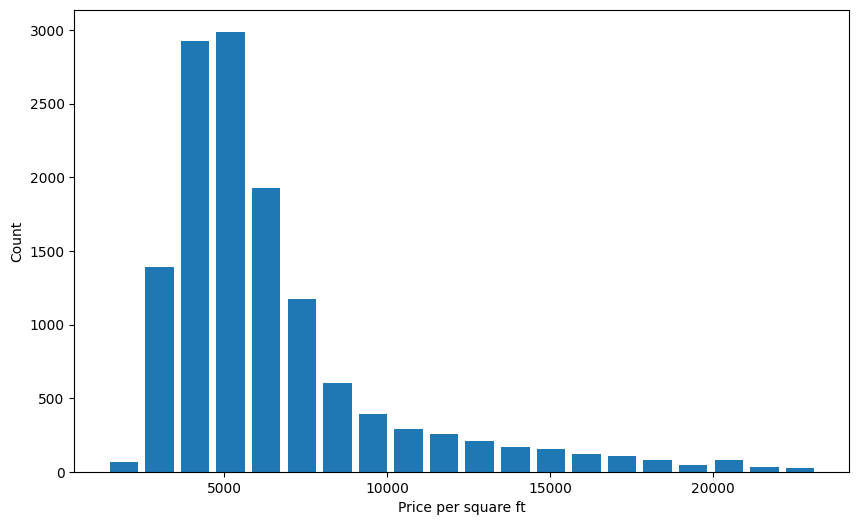

In [34]:
plt.hist(df3.price_per_sqft, bins=20, rwidth=0.8)
plt.xlabel('Price per square ft')
plt.ylabel('Count')
plt.show()

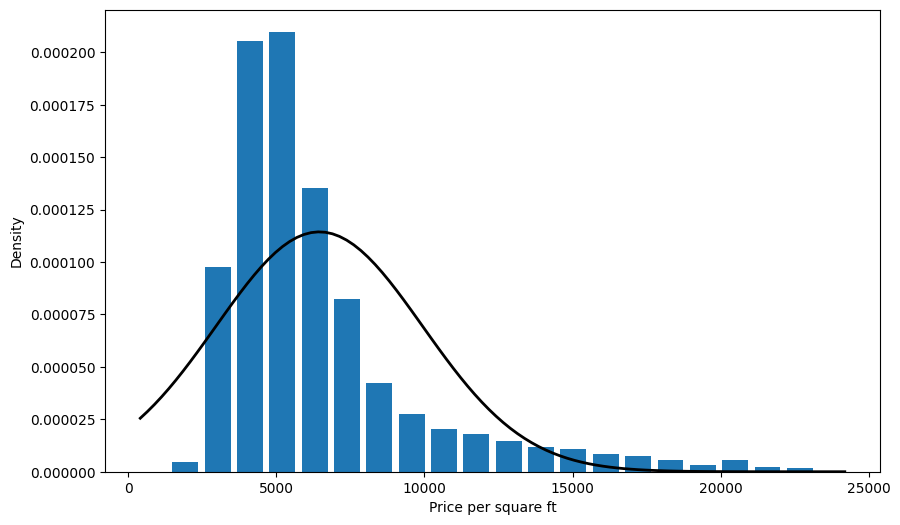

In [39]:
plt.hist(df3.price_per_sqft, bins=20, rwidth=0.8, density=True)
plt.xlabel('Price per square ft')
plt.ylabel('Density')

mu, std = norm.fit(df3.price_per_sqft)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
plt.show()

Our histogram is right-skewed. That’s why the fitted normal distribution (bell curve) doesn’t match well. Normal distributions are symmetric, but the data isn’t.

###Remove outliers using z score

In [40]:
df2['zscore'] = (df2.price_per_sqft-df2.price_per_sqft.mean())/df2.price_per_sqft.std()
df2.sample(10)

/tmp/ipython-input-722868599.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['zscore'] = (df2.price_per_sqft-df2.price_per_sqft.mean())/df2.price_per_sqft.std()


,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
4376,Bellandur,4 Bedroom,3600.0,4.0,260.00,4,7222,0.134833
8515,JP Nagar,3 BHK,2050.0,3.0,82.00,3,4000,-0.643236
4154,Nagarbhavi,2 Bedroom,1200.0,2.0,150.00,2,12500,1.409398
7601,Uttarahalli,2 BHK,1002.0,2.0,40.08,2,4000,-0.643236
12660,Dodda Nekkundi,3 BHK,1585.0,2.0,79.00,3,4984,-0.405613
6554,Electronic City Phase II,2 BHK,920.0,2.0,26.00,2,2826,-0.926741
7072,Electronics City Phase 1,2 BHK,1025.0,2.0,90.00,2,8780,0.511069
11119,Uttarahalli,3 BHK,1490.0,2.0,59.60,3,4000,-0.643236
1203,OMBR Layout,2 BHK,1078.0,2.0,65.00,2,6029,-0.153260
12249,Doddaballapur,1 BHK,654.0,1.0,49.00,1,7492,0.200034


In [41]:
outliers_z = df2[(df2.zscore<-4) | (df2.zscore>4)]
outliers_z.shape

(125, 8)

In [42]:
outliers_z.sample(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
8082,Nagarbhavi,4 Bedroom,1200.0,3.0,340.0,4,28333,5.232851
9853,Indira Nagar,5 Bedroom,2400.0,5.0,700.0,5,29166,5.434010
13186,other,4 Bedroom,1200.0,5.0,325.0,4,27083,4.930994
6134,Basavangudi,6 Bedroom,1754.0,6.0,650.0,6,37058,7.339820
12900,HAL 2nd Stage,5 Bedroom,2040.0,4.0,500.0,5,24509,4.309408


In [43]:
df4 = df2[(df2.zscore>-4)&(df2.zscore<4)]
df4.shape

(13047, 8)

In [44]:
df2.shape[0] - df4.shape[0]

125